In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from algorithms.auxiliares import *

In [ ]:
class SOM():
    def __init__(self,dims : tuple, 
                 config ={
                     "init" : 500,
                     "medium" : 1000,
                     "end": 3000
                 }):
        self.X_shape, self.Y_shape = dims
        self.weights = None
        self.config = config

        self.global_epoch =0
        

    def fit(self, X, visual_training = False):
        self.n_obs = X.shape[0]
        self.n_features = X.shape[1]
        # la matriz de pesos va a tener array de la cantidad de entradas

        
            
        self.weights = np.random.uniform(low = -0.5, 
                                         high = 0.5, 
                                         size = (
                                             self.X_shape, self.Y_shape, self.n_features
                                         ))
        
        total_epocas = sum(self.config.values())

        if visual_training == True:
            plt.ion()
            self._epoch_graph(X)

        for epoch in range(total_epocas):
            self.global_epoch = epoch

            #obtenemos los parametros acorde a la epoca
            tasa = self._get_learning_rate()
            radio = self._get_neighborhood_radius()

            indices = np.random.permutation(self.n_obs) #mmmm

            for idx in indices:
                x = X[idx]

                bmu_i, bmu_j = self._find_bmu(x) #buscamos la mejor neurona
                vecinos = self._get_neighborhood(radio, bmu_i, bmu_j)

                for i, j in vecinos:
                    self.weights[i,j] += tasa * (x- self.weights[i,j])

            
            if (visual_training == True) and self.global_epoch %300==0:
                self._epoch_graph(X)





        
    def _find_bmu(self, x):
        distancias = np.zeros((self.X_shape, self.Y_shape)) #grilla no datos

        for i in range(self.X_shape):
            for j in range(self.Y_shape):
                diff = x-self.weights[i,j]
                distancias[i,j] = np.sum(diff**2)
        
        bmu_i, bmu_j = np.unravel_index(np.argmin(distancias), distancias.shape)
        return bmu_i, bmu_j


    def _get_learning_rate(self):
        current_epoch = self.global_epoch
        if current_epoch < self.config["init"]:
            return 0.9
        if current_epoch>self.config["init"] + self.config["medium"]:
            return 0.01
        #caso estar en la transition_phase, igualdad de proporciones

        ratio = self.config["medium"] / (0.9-0.01)

        delta = (current_epoch - self.config["init"])/ratio
        return 0.9 - delta
    
    def _get_neighborhood_radius(self):
        current_epoch = self.global_epoch

        r_init = int(max(self.X_shape, self.Y_shape)/2)
        r_final = 0
        
        if current_epoch < self.config["init"]:
            return r_init

        if current_epoch>self.config["init"] + self.config["medium"]:
            return r_final
        
        inicio = self.config["init"]
        duracion = self.config["medium"]
        progreso = (current_epoch - inicio)/duracion

        radio_continuo = r_init - (r_init - r_final)*progreso
        return int(np.ceil(radio_continuo))

    def _get_neighborhood(self, radio, pos_i, pos_j):
        #dada una neurona me da los vecnios
        vecinos = [(pos_i, pos_j)]

        if radio ==0:
            return vecinos

        for r in range(1, radio+1):
            if pos_i - r >=0:
                vecinos.append((pos_i - r, pos_j))
            if pos_i + r <self.X_shape: #ancho de la girllaaa no X shapeee
                vecinos.append((pos_i + r, pos_j))
            if pos_j - r >=0:
                vecinos.append((pos_i, pos_j -r))
            if pos_j + r <self.Y_shape:
                vecinos.append((pos_i, pos_j + r))

        return vecinos
    
    def _epoch_graph(self, X=None):
    
        #asumimos datos 2D
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

        x_coords = self.weights[:,:,0] #agarramos coordenadas x de los pesos
        y_coords = self.weights [:,:,1]

        #unimos con lineas las vecinas
        for i in range(self.X_shape): #grillaaaa
            for j in range(self.Y_shape-1): #ni idea porque va para -1
                x_line = [x_coords[i,j], x_coords[i,j+1]] #unimos la actual con la siguiente en x
                y_line = [y_coords[i,j], y_coords[i, j+1]]
                ax1.plot(x_line, y_line, 'k-', linewidth=0.8, alpha=0.7)
        
        for i in range(self.X_shape - 1):
            for j in range(self.Y_shape):
                x_line = [x_coords[i, j], x_coords[i + 1, j]]
                y_line = [y_coords[i, j], y_coords[i + 1, j]]
                ax1.plot(x_line, y_line, 'k-', linewidth=0.8, alpha=0.7)

        # dibujamos las neuronas
        x_flat = x_coords.flatten()
        y_flat = y_coords.flatten()

        colores = []
        for i in range(self.X_shape):
            for j in range(self.Y_shape):
                colores.append(i / self.X_shape) #coloreamos un "degrade" por neurona renglon

        ax1.scatter(x_flat, y_flat, c=colores, cmap='viridis', s=80, marker='o', edgecolors='black', linewidth=0.5, zorder=3)

        #nos quedaria ver el grafico con la neurona
        
        
        # === 4. Configurar el gráfico ===
        ax1.set_title(f'SOM (Mapa topologico) - Época {self.global_epoch}')
        ax1.set_xlabel('Feature 1')
        ax1.set_ylabel('Feature 2')
        ax1.axis('equal')  # Misma escala en ambos ejes
        ax1.grid(True, alpha=0.3)
        
        # Fijar límites si hay datos (para no ver saltos)
        if X is not None:
            # Calcular BMU para cada punto y su color asociado
            bmu_colores = []
            bmu_indices = []
            
            for x in X:
                bmu_i, bmu_j = self._find_bmu(x)
                bmu_indices.append((bmu_i, bmu_j))
                # El color se define por la fila de la neurona ganadora (mismo criterio)
                bmu_colores.append(bmu_i / self.X_shape)
            
            # Dibujar los datos coloreados según su BMU
            ax2.scatter(X[:, 0], X[:, 1], c=bmu_colores, cmap='viridis', 
                    s=20, marker='.', alpha=0.7, zorder=1)
            
            # Dibujar CENTROIDES (marcadores de las neuronas en el espacio de datos)
            ax2.scatter(x_flat, y_flat, c='black', s=50, marker='x', 
                    linewidths=2, zorder=2, label='Centroides')
            
            ax2.set_title(f'Datos coloreados por BMU - Época {self.global_epoch}')
            ax2.set_xlabel('Feature 1')
            ax2.set_ylabel('Feature 2')
            ax2.axis('equal')
            ax2.grid(True, alpha=0.3)
            
            # Misma escala en ambos subplots
            x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
            y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
            ax1.set_xlim(x_min, x_max)
            ax1.set_ylim(y_min, y_max)
            ax2.set_xlim(x_min, x_max)
            ax2.set_ylim(y_min, y_max)
            
            ax2.legend()
        
        else:
            # Si no hay datos, mostrar mensaje
            ax2.text(0.5, 0.5, 'No hay datos para mostrar', 
                    transform=ax2.transAxes, ha='center', va='center')
            ax2.set_title('Datos no disponibles')
        
    plt.tight_layout()
    plt.pause(0.01)
        

        








        


<Figure size 640x480 with 0 Axes>

# ejercicio 1

Implemente el algoritmo de entrenamiento de un SOM bidimensional de forma que se pueda ver gráficamente el mapa topológico durante todo el proceso. Para poder observar el ordenamiento topológico, en el mapa grafique líneas de unión entre pares de neuronas vecinas. Realice las pruebas de ordenamiento topológico con los patrones provistos en los archivos `circulo.csv` y `te.csv`, usando un máximo de 1000 épocas de entrenamiento. Dichos datos fueron generados aleatoriamente con distribución uniforme dentro de un círculo de radio 1 centrado en el origen y una T como muestra la figura.

Para cada distribución grafique los datos de entrenamiento coloreando cada punto según la neurona ganadora correspondiente, y agregue el centroide de cada neurona con otro marcador.

Repita el entrenamiento con los datos en T pero para un SOM unidimensional con la misma cantidad de neuronas.

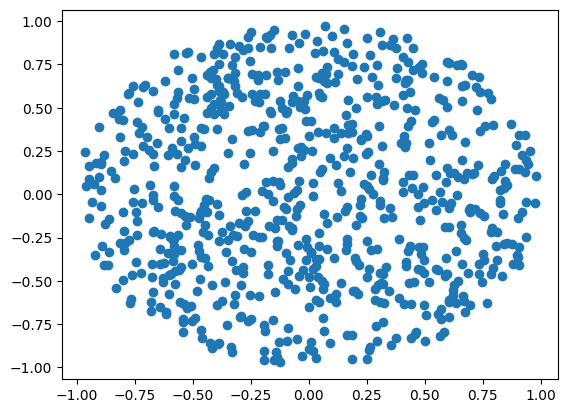

In [30]:
X = pd.read_csv("../data/circulo.csv").to_numpy()

plt.scatter(X[:, 0], X[:,1])

In [ ]:
som = SOM(dims=(5, 5))

som.fit(X, visual_training=True)